In [2]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [3]:
customers = pd.read_excel("transformed_data/customers_transformed.xlsx")

orders = pd.read_excel("transformed_data/orders_transformed.xlsx")

order_items = pd.read_excel("transformed_data/order_items_transformed.xlsx")

payments = pd.read_excel("transformed_data/payments_transformed.xlsx")

products = pd.read_excel("transformed_data/products_transformed.xlsx")

reviews = pd.read_excel("transformed_data/reviews_transformed.xlsx")

sellers = pd.read_excel("transformed_data/sellers_transformed.xlsx")

geolocation = pd.read_excel("transformed_data/geolocation_transformed.xlsx")

### merge required tables

In [4]:
rfm_data = orders.merge(
    payments,
    on="order_id"
)

### create reference date( latest purchase date)

In [6]:
reference_date = orders[
    "order_purchase_timestamp"
].max()

### create RFM table

In [8]:
rfm = rfm_data.groupby(
    "customer_id"
).agg({
    "order_purchase_timestamp": lambda x: (
        reference_date - x.max()
    ).days,

    "order_id": "count",

    "payment_value": "sum"
}).reset_index()

### rename columns

In [9]:
rfm.columns = [
    "customer_id",
    "Recency",
    "Frequency",
    "Monetary"
]

In [10]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00002,22,6,32448.28
1,CUST00003,124,7,36020.30
2,CUST00004,123,2,3833.03
3,CUST00005,175,3,5770.05
4,CUST00007,250,2,5516.34


### feature scaling

In [12]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

### elbow method(to find best number of clusters)

In [14]:
wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

### plot elbow curve

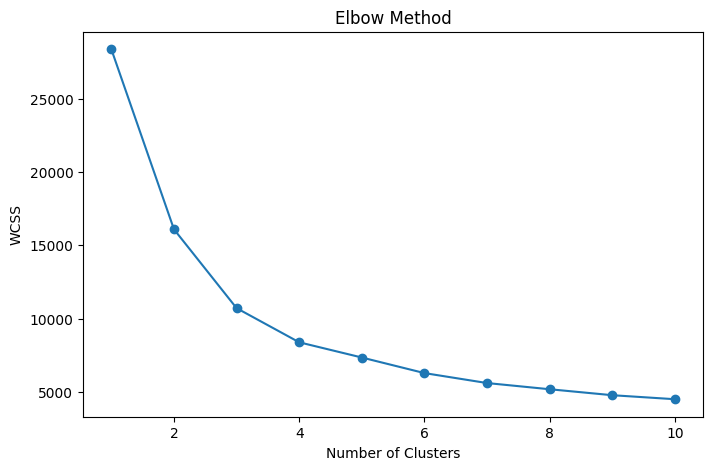

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

### apply k-means

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

### check clusters

In [20]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster
0,CUST00002,22,6,32448.28,0
1,CUST00003,124,7,36020.30,3
2,CUST00004,123,2,3833.03,4
3,CUST00005,175,3,5770.05,4
4,CUST00007,250,2,5516.34,1


### cluster analysis

In [22]:
cluster_summary = rfm.groupby(
    "Cluster"
)[["Recency", "Frequency", "Monetary"]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,124.099077,5.214489,22119.453398
1,310.564589,2.652369,10874.155656
2,546.575142,1.758733,7179.616466
3,102.476636,8.521028,36952.862629
4,91.235317,2.678935,10620.720482


### visualize clusters

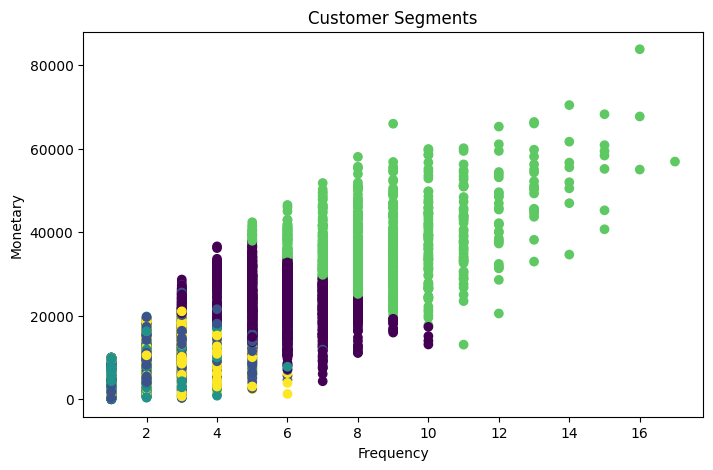

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.title("Customer Segments")

plt.show()

### summary of clusters

In [26]:
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,124.099077,5.214489,22119.453398
1,310.564589,2.652369,10874.155656
2,546.575142,1.758733,7179.616466
3,102.476636,8.521028,36952.862629
4,91.235317,2.678935,10620.720482


In [28]:
# Cluster	Interpretation	Suggested Label
# 3	Highest Frequency + Highest Monetary + Low Recency	VIP Customers
# 0	Good Frequency + High Spending	Loyal Customers
# 4	Recent customers but lower spending	New Customers
# 1	Older purchases + low activity	At-Risk Customers
# 2	Very high recency + lowest activity	Inactive Customers

### creating labels

In [29]:
rfm["Customer_Segment"] = rfm["Cluster"].map({
    0: "Loyal Customers",
    1: "At-Risk Customers",
    2: "Inactive Customers",
    3: "VIP Customers",
    4: "New Customers"
})

In [31]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,CUST00002,22,6,32448.28,0,Loyal Customers
1,CUST00003,124,7,36020.30,3,VIP Customers
2,CUST00004,123,2,3833.03,4,New Customers
3,CUST00005,175,3,5770.05,4,New Customers
4,CUST00007,250,2,5516.34,1,At-Risk Customers


### visualize customer segments

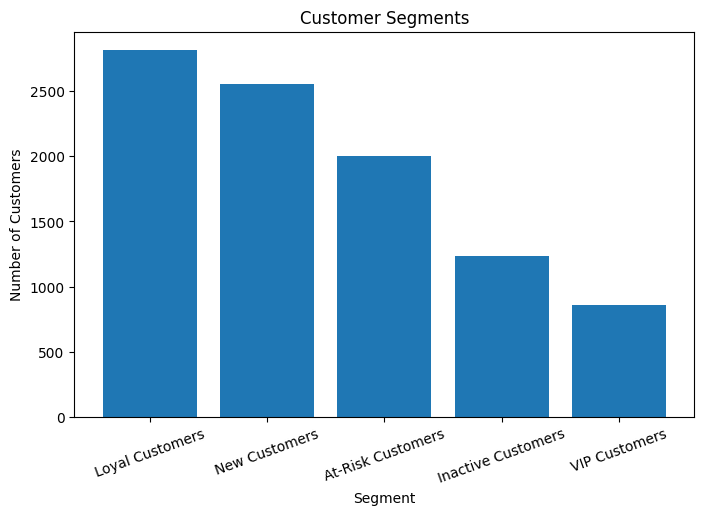

In [33]:
segment_counts = rfm["Customer_Segment"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xticks(rotation=20)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

### saving dataset

In [34]:
rfm.to_csv(
    "customer_segmentation.csv",
    index=False
)